# Chapter 13 — Deformation and Strain
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 13 — Deformation and Strain.

Strain is defined at a point, as the limit of $\Delta L/L$ when the length shrinks to nothing. Every instrument reports it over a finite length and area. Where the strain is uniform the two agree; beside a hole they do not, and the difference can be computed.

In 1912 E. Preuß, at Darmstadt, measured the stress at the edge of holes 15 to 70 mm in diameter in steel bars about 120 mm wide, with a mirror extensometer of his own design that spanned 3.3 mm (Preuß, *Z. VDI* 56 (1912) 1780–1783). He found the edge stress 2.35, 2.35, 2.13 and 2.24 times the mean net-section stress and concluded that it did not depend materially on the hole size. The elastic solutions for a hole in a strip of finite width (Howland 1930; Heywood 1952, as tabulated by Deghboudj et al., *U.P.B. Sci. Bull. D* 78(4), 2016) say it falls from about 2.7 to 2.1 over that range.

**This notebook demonstrates:**
1. Kirsch's (1898) solution for a circular hole in a wide plate under uniaxial tension, turned into the strain a load-direction gage would read beside the hole (Eq. 13.4), and its closed-form average across a grid (Eq. 13.5).
2. The chapter's worked example: what a 6 mm gage, and a 0.8 mm gage, read beside a 20 mm and a 100 mm hole, by the closed form and by a full average over the grid area.
3. What Preuß's 3.3 mm span did at the edge of each of his four holes.
4. Figure 13.2: the strain decay beside two holes with a gage footprint drawn to scale, and Preuß's measurements against the later finite-width solutions.
5. (Notebook only) the strain field of pure bending, and volumetric strain.

The Kirsch field is exact for an infinite plate; near the edge of a hole in a strip it is a close approximation, and it is used here only for the *ratio* of an averaged reading to the peak.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11.5, 'axes.titlesize': 11.5})

# The printed figure is written to the chapter's media folder; its file name
# matches the \includegraphics call in Chapter 13.
OUT_DIR = Path("../src/media/ch13")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Kirsch's hole, and what a grid beside it reads

Take a circular hole of radius $a$ in a wide plate, with a uniform tension $\sigma_\infty$ along $y$ far away. Along the line through the hole's center at right angles to the load (the $x$ axis), Kirsch's solution gives the stress along the load and the radial stress across it, with $\rho = a/r$:

$$\sigma_y = \sigma_\infty\left(1 + \tfrac12\rho^2 + \tfrac32\rho^4\right), \qquad \sigma_x = \tfrac32\,\sigma_\infty\left(\rho^2 - \rho^4\right)$$

Hooke's law for plane stress (Eq. 13.3) turns them into the strain a gage aligned with the load reads:

$$\frac{E\,\varepsilon_y}{\sigma_\infty} = 1 + \frac{1-3\nu}{2}\,\rho^2 + \frac{3(1+\nu)}{2}\,\rho^4 \qquad \text{(Eq. 13.4)}$$

At the bore ($\rho = 1$) this is exactly 3, for any $\nu$. A grid whose inner and outer edges sit at $r_1$ and $r_2$ on that line averages it to

$$\frac{E\,\bar\varepsilon_y}{\sigma_\infty} = 1 + \frac{1-3\nu}{2}\,\frac{a^2}{r_1 r_2} + \frac{1+\nu}{2}\,\frac{a^4\left(r_1^2 + r_1 r_2 + r_2^2\right)}{r_1^3\, r_2^3} \qquad \text{(Eq. 13.5)}$$

Eq. 13.5 averages across the grid's width only. A real grid also has length, running along the load, tangent to the bore, where the strain falls much more slowly. The function `grid_average` below integrates the full Kirsch field over the grid's area to show how little that adds.

In [2]:
NU = 0.30   # Poisson's ratio of steel, as in the chapter's worked example

def kirsch_cartesian(x, y, a, s_inf=1.0):
    # Kirsch (1898): stresses around a circular hole of radius a, remote tension s_inf along y.
    # Polar angle theta is measured from the load (y) axis. Returns (sigma_x, sigma_y).
    r = np.hypot(x, y)
    th = np.arctan2(x, y)
    q = (a / r) ** 2
    s_r = s_inf / 2 * (1 - q) + s_inf / 2 * (1 - 4 * q + 3 * q**2) * np.cos(2 * th)
    s_t = s_inf / 2 * (1 + q) - s_inf / 2 * (1 + 3 * q**2) * np.cos(2 * th)
    t_rt = -s_inf / 2 * (1 + 2 * q - 3 * q**2) * np.sin(2 * th)
    er = (np.sin(th), np.cos(th))      # radial unit vector in (x, y)
    et = (np.cos(th), -np.sin(th))     # tangential unit vector in (x, y)
    sxx = s_r * er[0]**2 + s_t * et[0]**2 + 2 * t_rt * er[0] * et[0]
    syy = s_r * er[1]**2 + s_t * et[1]**2 + 2 * t_rt * er[1] * et[1]
    return sxx, syy

def strain_y(x, y, a, nu=NU):
    # E * eps_y / sigma_inf, plane stress
    sxx, syy = kirsch_cartesian(x, y, a)
    return syy - nu * sxx

def eq_13_4(r, a, nu=NU):
    rho = a / r
    return 1 + (1 - 3 * nu) / 2 * rho**2 + 3 * (1 + nu) / 2 * rho**4

def eq_13_5(r1, r2, a, nu=NU):
    return (1 + (1 - 3 * nu) / 2 * a**2 / (r1 * r2)
              + (1 + nu) / 2 * a**4 * (r1**2 + r1 * r2 + r2**2) / (r1**3 * r2**3))

def grid_average(a, length, width, margin, n=401):
    # Mean of E*eps_y/sigma_inf over a grid aligned with the load, centered on the
    # transverse axis, inner edge `margin` from the bore, `width` across the gradient.
    xs = np.linspace(a + margin, a + margin + width, n)
    ys = np.linspace(-length / 2, length / 2, n)
    X, Y = np.meshgrid(xs, ys)
    return strain_y(X, Y, a).mean()

# Checks: the closed forms agree with the full field
r = np.linspace(10, 40, 7)
assert np.allclose(eq_13_4(r, 10), strain_y(r, 0 * r, 10))
assert abs(eq_13_4(10, 10) - 3) < 1e-12
print("Eq. 13.4 matches the Kirsch field on the transverse axis; peak = 3.000")
print(f"Stress one radius out from the bore (r = 2a): {1 + 0.5*0.25 + 1.5*0.0625:.2f} x sigma_inf (Chapter 36 quotes about 1.2)")

Eq. 13.4 matches the Kirsch field on the transverse axis; peak = 3.000
Stress one radius out from the bore (r = 2a): 1.22 x sigma_inf (Chapter 36 quotes about 1.2)


### The chapter's worked example

A gage with a 6 mm grid length and a 3 mm wide grid, aligned with the load, sits beside the hole with the grid's inner edge 1 mm from the bore. A miniature gage with a 0.8 mm square grid sits 0.25 mm from the bore. Steel, $\nu = 0.30$, remote strain 250 µε (σ∞ = 50 MPa at E = 200 GPa).

In [3]:
REMOTE_UE = 250.0   # remote strain, microstrain
cases = [  # (label, hole diameter mm, grid length mm, grid width mm, margin mm)
    ("6 mm gage, 20 mm hole",   20, 6.0, 3.0, 1.0),
    ("6 mm gage, 100 mm hole", 100, 6.0, 3.0, 1.0),
    ("0.8 mm gage, 20 mm hole", 20, 0.8, 0.8, 0.25),
]
print(f"{'case':26s} {'Eq13.5':>8s} {'/peak':>7s} {'full grid':>10s} {'/peak':>7s} {'reads ue':>9s}")
for label, D, L, w, m in cases:
    a = D / 2
    closed = eq_13_5(a + m, a + m + w, a)
    full = grid_average(a, L, w, m)
    print(f"{label:26s} {closed:8.3f} {closed/3:7.3f} {full:10.3f} {full/3:7.3f} {closed*REMOTE_UE:9.0f}")

# Hand-calculation steps for the 20 mm hole (a = 10, r1 = 11, r2 = 14)
a, r1, r2 = 10.0, 11.0, 14.0
t1 = a**2 / (r1 * r2)
t2 = a**4 * (r1**2 + r1 * r2 + r2**2) / (r1**3 * r2**3)
print(f"\na^2/(r1 r2) = {t1:.4f};  x (1-3nu)/2 = {(1-3*NU)/2*t1:.4f}")
print(f"a^4(r1^2+r1r2+r2^2)/(r1^3 r2^3) = {t2:.4f};  x (1+nu)/2 = {(1+NU)/2*t2:.4f}")
print(f"sum = {1 + (1-3*NU)/2*t1 + (1+NU)/2*t2:.3f}")

case                         Eq13.5   /peak  full grid   /peak  reads ue
6 mm gage, 20 mm hole         1.871   0.624      1.808   0.603       468
6 mm gage, 100 mm hole        2.654   0.885      2.644   0.881       664
0.8 mm gage, 20 mm hole       2.567   0.856      2.563   0.854       642

a^2/(r1 r2) = 0.6494;  x (1-3nu)/2 = 0.0325
a^4(r1^2+r1r2+r2^2)/(r1^3 r2^3) = 1.2896;  x (1+nu)/2 = 0.8382
sum = 1.871


### Preuß's 3.3 mm span at the edge of his four holes

Preuß's instrument measured strain along the load over 3.3 mm, at the edge of each hole. Averaging the Kirsch strain along that span (tangent to the bore) costs a few percent at the smallest hole; any distance between the knife edges and the bore costs more. The peak values for his width ratios come from Heywood's formula $K_{tn} = 2 + (1 - d/W)^3$ and Howland's solution, as tabulated by Deghboudj et al. (2016), Table 1.

In [4]:
SPAN = 3.3          # mm, Preuss's gauge length
WIDTH = 120.0       # mm, bar width ("etwa 120 mm")
preuss_D = np.array([15, 30, 50, 70])                 # mm hole diameters
preuss_ratio = np.array([2.352, 2.345, 2.128, 2.244]) # sigma_max / sigma_net (Zahlentafel 2)

def heywood_net(dW):
    return 2 + (1 - dW)**3

# Howland net SCF, Deghboudj et al. (2016) Table 1
howland_dW = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
howland_Kn = np.array([2.731, 2.519, 2.357, 2.239, 2.157, 2.102])

print(f"{'D mm':>5s} {'d/W':>6s} {'span/a':>7s} {'measured':>9s} {'Heywood':>8s} {'meas/theory':>11s} "
      f"{'avg@bore':>9s} {'avg@0.25mm':>11s}")
for D, meas in zip(preuss_D, preuss_ratio):
    a = D / 2
    dW = D / WIDTH
    ys = np.linspace(-SPAN / 2, SPAN / 2, 2001)
    on_bore = strain_y(a + 0 * ys, ys, a).mean() / 3
    set_back = strain_y(a + 0.25 + 0 * ys, ys, a).mean() / 3
    print(f"{D:5d} {dW:6.3f} {SPAN/a:7.2f} {meas:9.3f} {heywood_net(dW):8.3f} {meas/heywood_net(dW):11.3f} "
          f"{on_bore:9.3f} {set_back:11.3f}")

 D mm    d/W  span/a  measured  Heywood meas/theory  avg@bore  avg@0.25mm
   15  0.125    0.44     2.352    2.670       0.881     0.942       0.873
   30  0.250    0.22     2.345    2.422       0.968     0.984       0.944
   50  0.417    0.13     2.128    2.198       0.968     0.994       0.969
   70  0.583    0.09     2.244    2.072       1.083     0.997       0.979


### Figure 13.2

(a) The strain along the load, beside a 20 mm hole (solid) and a 100 mm hole (dashed), against distance from the bore. The hatched band is the footprint of the 6 mm gage's 3 mm wide grid, 1 mm off the bore; the short horizontal bars are what that grid reads by Eq. 13.5 (1.87 and 2.65; a full-area average gives 1.81 and 2.64). (b) Preuß's four measurements (filled circles) against Heywood's formula (solid curve) and Howland's solution (open squares).

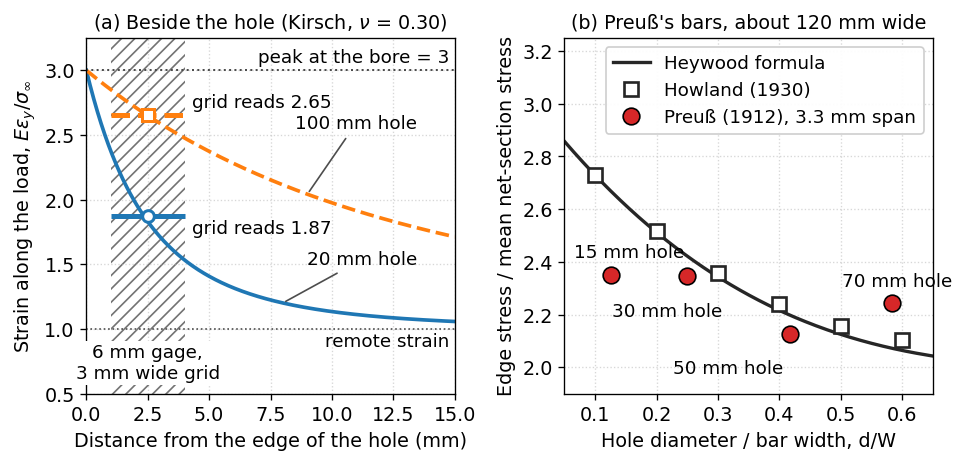

In [5]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(8.2, 4.0))

# ---- (a) strain decay beside the hole, gage footprint to scale
dist = np.linspace(0, 15, 600)               # mm from the bore
GL, GW, GM = 6.0, 3.0, 1.0
styles = [(20, '-', 'tab:blue', 'o'), (100, '--', 'tab:orange', 's')]
for D, ls, col, mk in styles:
    a = D / 2
    axa.plot(dist, eq_13_4(a + dist, a), ls, color=col, lw=2.2)
    reading = eq_13_5(a + GM, a + GM + GW, a)     # Eq. 13.5, as in the chapter's text
    axa.hlines(reading, GM, GM + GW, colors=col, linestyles=ls, lw=3.0)
    axa.plot([GM + GW / 2], [reading], marker=mk, color=col, ms=7, mfc='white', mew=1.8)
axa.axvspan(GM, GM + GW, facecolor='none', edgecolor='0.45', hatch='///', lw=0)
axa.axhline(3.0, color='0.3', ls=':', lw=1.2)
axa.axhline(1.0, color='0.3', ls=':', lw=1.0)
axa.text(14.8, 3.03, 'peak at the bore = 3', ha='right', va='bottom', fontsize=11)
axa.text(14.8, 0.97, 'remote strain', ha='right', va='top', fontsize=11)
axa.annotate('100 mm hole', xy=(9.0, eq_13_4(50 + 9.0, 50)), xytext=(8.5, 2.55),
             fontsize=11, arrowprops=dict(arrowstyle='-', color='0.3'))
axa.annotate('20 mm hole', xy=(8.0, eq_13_4(10 + 8.0, 10)), xytext=(9.0, 1.5),
             fontsize=11, arrowprops=dict(arrowstyle='-', color='0.3'))
r20 = eq_13_5(10 + GM, 10 + GM + GW, 10); r100 = eq_13_5(50 + GM, 50 + GM + GW, 50)
axa.text(GM + GW + 0.3, r20 - 0.02, f'grid reads {r20:.2f}', fontsize=11, va='top')
axa.text(GM + GW + 0.3, r100 + 0.03, f'grid reads {r100:.2f}', fontsize=11, va='bottom')
axa.text(GM + GW / 2, 0.62, '6 mm gage,\n3 mm wide grid', ha='center', fontsize=11,
         bbox=dict(facecolor='white', edgecolor='none', pad=1.5))
axa.set_xlim(0, 15); axa.set_ylim(0.5, 3.25)
axa.set_xlabel('Distance from the edge of the hole (mm)')
axa.set_ylabel(r'Strain along the load, $E\varepsilon_y/\sigma_\infty$')
axa.set_title('(a) Beside the hole (Kirsch, $\\nu$ = 0.30)')
axa.grid(True, ls=':', alpha=0.5)

# ---- (b) Preuss 1912 against later finite-width solutions
dW = np.linspace(0.05, 0.65, 200)
axb.plot(dW, heywood_net(dW), '-', color='0.15', lw=2, label='Heywood formula')
axb.plot(howland_dW, howland_Kn, 's', color='0.15', mfc='white', ms=8, mew=1.6,
         label='Howland (1930)')
axb.plot(preuss_D / WIDTH, preuss_ratio, 'o', color='tab:red', ms=10, mec='k',
         label='Preuß (1912), 3.3 mm span')
for D, v in zip(preuss_D, preuss_ratio):
    off = {15: (-22, 10), 30: (-45, -24), 50: (-70, -24), 70: (-30, 10)}[D]
    axb.annotate(f'{D} mm hole', xy=(D / WIDTH, v), xytext=off,
                 textcoords='offset points', fontsize=11)
axb.set_xlim(0.05, 0.65); axb.set_ylim(1.9, 3.25)
axb.set_xlabel('Hole diameter / bar width, d/W')
axb.set_ylabel('Edge stress / mean net-section stress')
axb.set_title('(b) Preuß\'s bars, about 120 mm wide')
axb.legend(loc='upper right', fontsize=11, framealpha=0.95)
axb.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig13_nb1_hole_gage_averaging.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 2 — (Notebook only) Strain tensor from a known displacement field

For pure bending the displacement field is known analytically. Differentiating it gives the strain components directly, the same operation digital image correlation performs numerically on measured surface displacements. $\varepsilon_{xx}$ is antisymmetric about the neutral axis, $\varepsilon_{yy}$ is the Poisson response scaled by $-\nu$, and $\gamma_{xy}$ is zero because no shear acts on horizontal planes in pure bending.

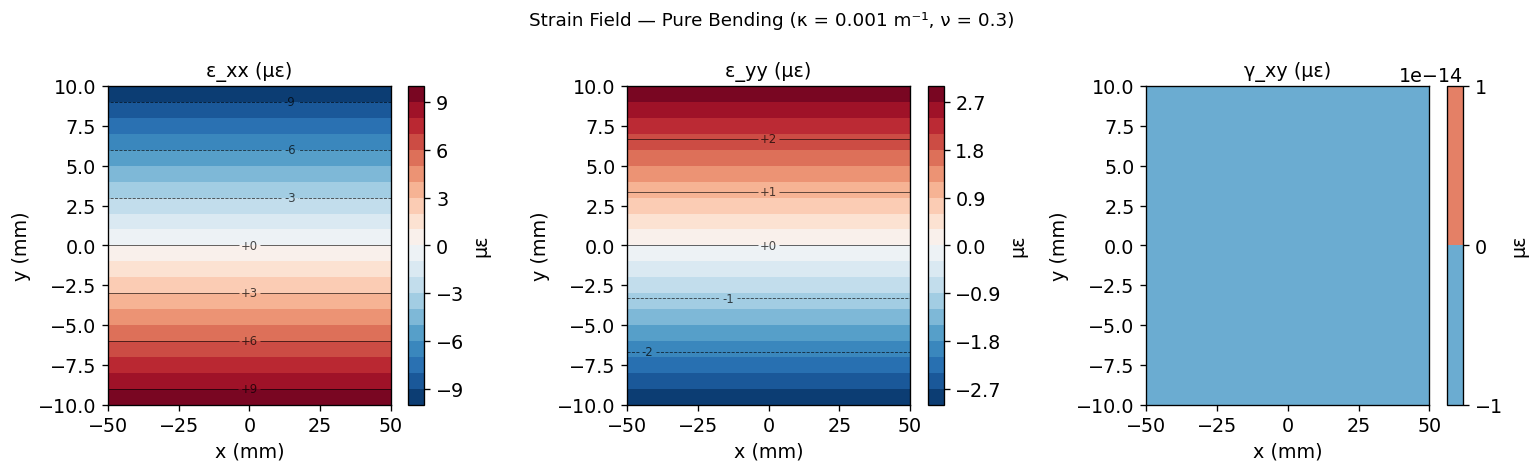

Max ε_xx at outer fiber (y = ±10 mm): 10 με


In [6]:
# Pure-bending displacement field (plane stress):
#     u(x, y) = -kappa * x * y
#     v(x, y) =  kappa/2 * (x**2 + nu * y**2)
# where kappa = curvature = M / (E*I). Differentiating this analytical field
# gives the strain components directly — the same operation digital image
# correlation performs numerically on measured surface displacements.

CURVATURE = 0.001          # kappa, beam curvature [1/m]
POISSON = 0.3              # nu, Poisson's ratio [-]
BEAM_HALF_LENGTH = 0.05    # x spans +/- this [m]
BEAM_HALF_HEIGHT = 0.01    # y spans +/- this; +/-HEIGHT are the outer fibers [m]
N_X, N_Y = 15, 10          # grid resolution in x and y


def bending_strains(kappa, nu, X, Y):
    """Return (eps_xx, eps_yy, gam_xy) for a pure-bending displacement field.

    Derived by differentiating u = -kappa*x*y, v = kappa/2*(x**2 + nu*y**2):
        eps_xx = du/dx        = -kappa * y
        eps_yy = dv/dy        =  kappa * nu * y   (Poisson response)
        gam_xy = du/dy + dv/dx = 0                (no shear in pure bending)
    """
    eps_xx = -kappa * Y
    eps_yy = kappa * nu * Y
    gam_xy = np.zeros_like(X)
    return eps_xx, eps_yy, gam_xy


x = np.linspace(-BEAM_HALF_LENGTH, BEAM_HALF_LENGTH, N_X)   # m
y = np.linspace(-BEAM_HALF_HEIGHT, BEAM_HALF_HEIGHT, N_Y)   # m
X, Y = np.meshgrid(x, y)

eps_xx, eps_yy, gam_xy = bending_strains(CURVATURE, POISSON, X, Y)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in zip(axes,
                           [eps_xx * 1e6, eps_yy * 1e6, gam_xy * 1e6],
                           ['ε_xx (με)', 'ε_yy (με)', 'γ_xy (με)']):
    im = ax.contourf(X * 1000, Y * 1000, data, levels=20, cmap='RdBu_r')
    # Labeled black contour lines keep sign + magnitude legible in grayscale /
    # B&W print, where the diverging red<->blue map collapses to similar greys.
    if np.ptp(data) > 1e-6:
        cs = ax.contour(X * 1000, Y * 1000, data, levels=6, colors='k',
                        linewidths=0.5, alpha=0.7)
        ax.clabel(cs, inline=True, fontsize=7, fmt='%+.0f')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='με')
fig.suptitle(f'Strain Field — Pure Bending (κ = {CURVATURE} m⁻¹, ν = {POISSON})',
             fontsize=11)
plt.tight_layout()
# Notebook-only figure: the book does not print it.
NB_ONLY_DIR = Path('figures/ch13')
NB_ONLY_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(NB_ONLY_DIR / 'strain_field_bending.png', bbox_inches='tight', dpi=300)
plt.show()

outer_fiber_strain = CURVATURE * BEAM_HALF_HEIGHT * 1e6
print(f"Max ε_xx at outer fiber (y = ±{BEAM_HALF_HEIGHT * 1000:.0f} mm): {outer_fiber_strain:.0f} με")

---
## 3 — (Notebook only) Volumetric strain

The trace of the strain tensor, $\varepsilon_{xx} + \varepsilon_{yy} + \varepsilon_{zz}$, is the fractional change in volume. In uniaxial stress it equals $\varepsilon_x(1 - 2\nu)$, which vanishes for an incompressible material ($\nu = 0.5$).

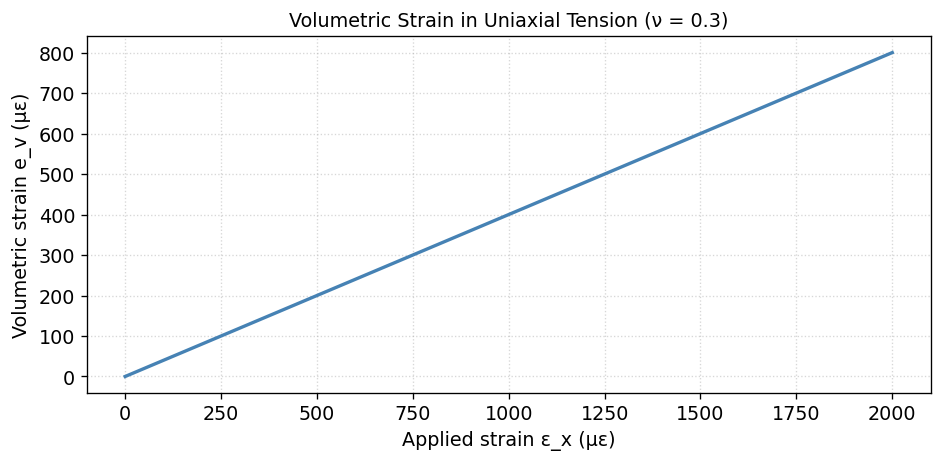

At ε_x = 1000 με: volumetric strain = 400 με
For ν = 0.5 (incompressible): volumetric strain = 0


In [7]:
# Volumetric strain (dilatation) = trace of the strain tensor = eps_xx + eps_yy + eps_zz.
# For a uniaxial STRESS state (sigma_x only): eps_yy = eps_zz = -nu*eps_xx, so
#     e_v = eps_axial * (1 - 2*nu).
# At nu = 0.5 the material is incompressible and e_v vanishes for any strain.

NU_STEEL = 0.3
MAX_STRAIN = 2000e-6       # sweep applied axial strain 0 -> 2000 microstrain [-]
N_POINTS = 200
REF_STRAIN = 1000e-6       # reference point reported below [-]


def volumetric_strain(eps_axial, nu):
    """Dilatation for a uniaxial stress state: e_v = eps_axial * (1 - 2*nu)."""
    return eps_axial * (1 - 2 * nu)


eps_x = np.linspace(0, MAX_STRAIN, N_POINTS)
ev = volumetric_strain(eps_x, NU_STEEL)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_x * 1e6, ev * 1e6, 'steelblue', lw=2)
ax.set_xlabel('Applied strain ε_x (με)')
ax.set_ylabel('Volumetric strain e_v (με)')
ax.set_title(f'Volumetric Strain in Uniaxial Tension (ν = {NU_STEEL})')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
# This figure is a notebook-only exploration; the book does not print it, so it is
# written to a local folder rather than into the book's media tree.
plt.savefig(NB_ONLY_DIR / 'volumetric_strain.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"At ε_x = {REF_STRAIN * 1e6:.0f} με: volumetric strain = {volumetric_strain(REF_STRAIN, NU_STEEL) * 1e6:.0f} με")
print("For ν = 0.5 (incompressible): volumetric strain = 0")

---
## Where to take this next

- **Move the gage.** Sweep the margin from 0 to 2 mm in `grid_average` for a 20 mm hole and plot the reading against it. The first quarter millimetre costs more than the grid length does.
- **Move to the top of the hole.** On the load axis ($\theta = 0$) the hoop stress at the bore is $-\sigma_\infty$, compressive and running across the load. Write a `strain_x` function ($\sigma_x - \nu\sigma_y$) and average it over a grid aligned across the load there.
- **Correct a reading.** Given a reading from a grid of known size and position, invert Eq. 13.5 for $\sigma_\infty$ and hence the peak. Chapter 36 does the same with an FEA field where no closed form exists.
- **Feed in real DIC displacements** in Section 2 and differentiate them with `np.gradient`; see how differentiation amplifies noise.